# Replication
## Goal of this project: 
Produce a replication of the work of: *Iacobucci, I., Zeng, A.G.X., Gao, Q. et al. Multipotent lineage potential in B cell acute lymphoblastic leukemia is associated with distinct cellular origins and clinical features. Nat Cancer 6, 1242–1262 (2025). https://doi.org/10.1038/s43018-025-00987-2*
Sample SCPCS000358
C:\Users\sambe\Documents\bigdata\High-Hyperdiploid\SCPCS000358

##Steps:
1. Download relevant libraries into pixi or conda environment.
2. Load relevant Anndata into my kernal.
3. View and think about this piece of data and its paramenters.
4. QC the data and clean it.
5. Normalise the dataset
6. Identify highly variable genes (feature selection)
7. Dimensional reduction of data (PCA and UMAP)
8. Observe the UMAP and its appearance, try and find batch effects. (If batch effects present determine a batch correction tool for use.)
9. Cluster with Leiden algorithm 
10. Annotate clusters, using Celltypist or Professional opinion. Long step requires lots of knowledge.
11. Repeat data integration and try and find more batch effects. 
12. Repeat and loop back if necessary to identify interesting phenomenom.

Environment setup:
Created conda environment "sc-exp"
>conda create -n sc-exp python=3.11
>conda install -c conda-forge scanpy pandas numpy ipykernel jupyter nbformat nbclient ipykernel seaborn
Altered .vscode/settings.json to make default kernal sc-exp

Hosted on WSL inside VisualStudioCode IDE.

## Loading Data

In [2]:
#Importing relevant libraries
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import anndata
from scipy.stats import median_abs_deviation

import os
print(os.getcwd())
sc.settings.figdir = "../output/plots"

/home/lizalfos/sc-explorations/scripts


In [3]:
anndata = sc.read_h5ad("/home/lizalfos/sc-explorations/data/high-hyperdiploid/SCPCS000358/SCPCL000629_processed_rna.h5ad")
print(anndata)
# alternative path /mnt/c/Users/sambe/Documents/bigdata/High-Hyperdiploid/SCPCS000358/
# To access WSL files through windows remember to use "\\wsl$" in file explorer.

AnnData object with n_obs × n_vars = 9104 × 60319
    obs: 'barcodes', 'sum', 'detected', 'subsets_mito_sum', 'subsets_mito_detected', 'subsets_mito_percent', 'total', 'prob_compromised', 'miQC_pass', 'scpca_filter', 'sizeFactor', 'cluster', 'singler_celltype_ontology', 'singler_celltype_annotation', 'cellassign_celltype_annotation', 'cellassign_celltype_ontology', 'cellassign_max_prediction', 'consensus_celltype_annotation', 'consensus_celltype_ontology', 'library_id', 'sample_id', 'scpca_project_id', 'submitter_id', 'participant_id', 'submitter', 'age', 'age_timing', 'sex', 'diagnosis', 'subdiagnosis', 'tissue_location', 'disease_timing', 'organism', 'is_xenograft', 'is_cell_line', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'organism_ontology_id', 'self_reported_ethnicity_ontology_term_id', 'disease_ontology_term_id', 'tissue_ontology_term_id', 'assay_ontology_term_id', 'suspension_type', 'is_primary_data'
    var: 'gene_ids', 'gene_symbol', 'mean', 'detected', 'fe

/home/lizalfos/miniconda3/envs/sc-rep/lib/python3.13/site-packages/matplotlib/colors.py:2294: RuntimeWarning: invalid value encountered in subtract
  resdat -= vmin


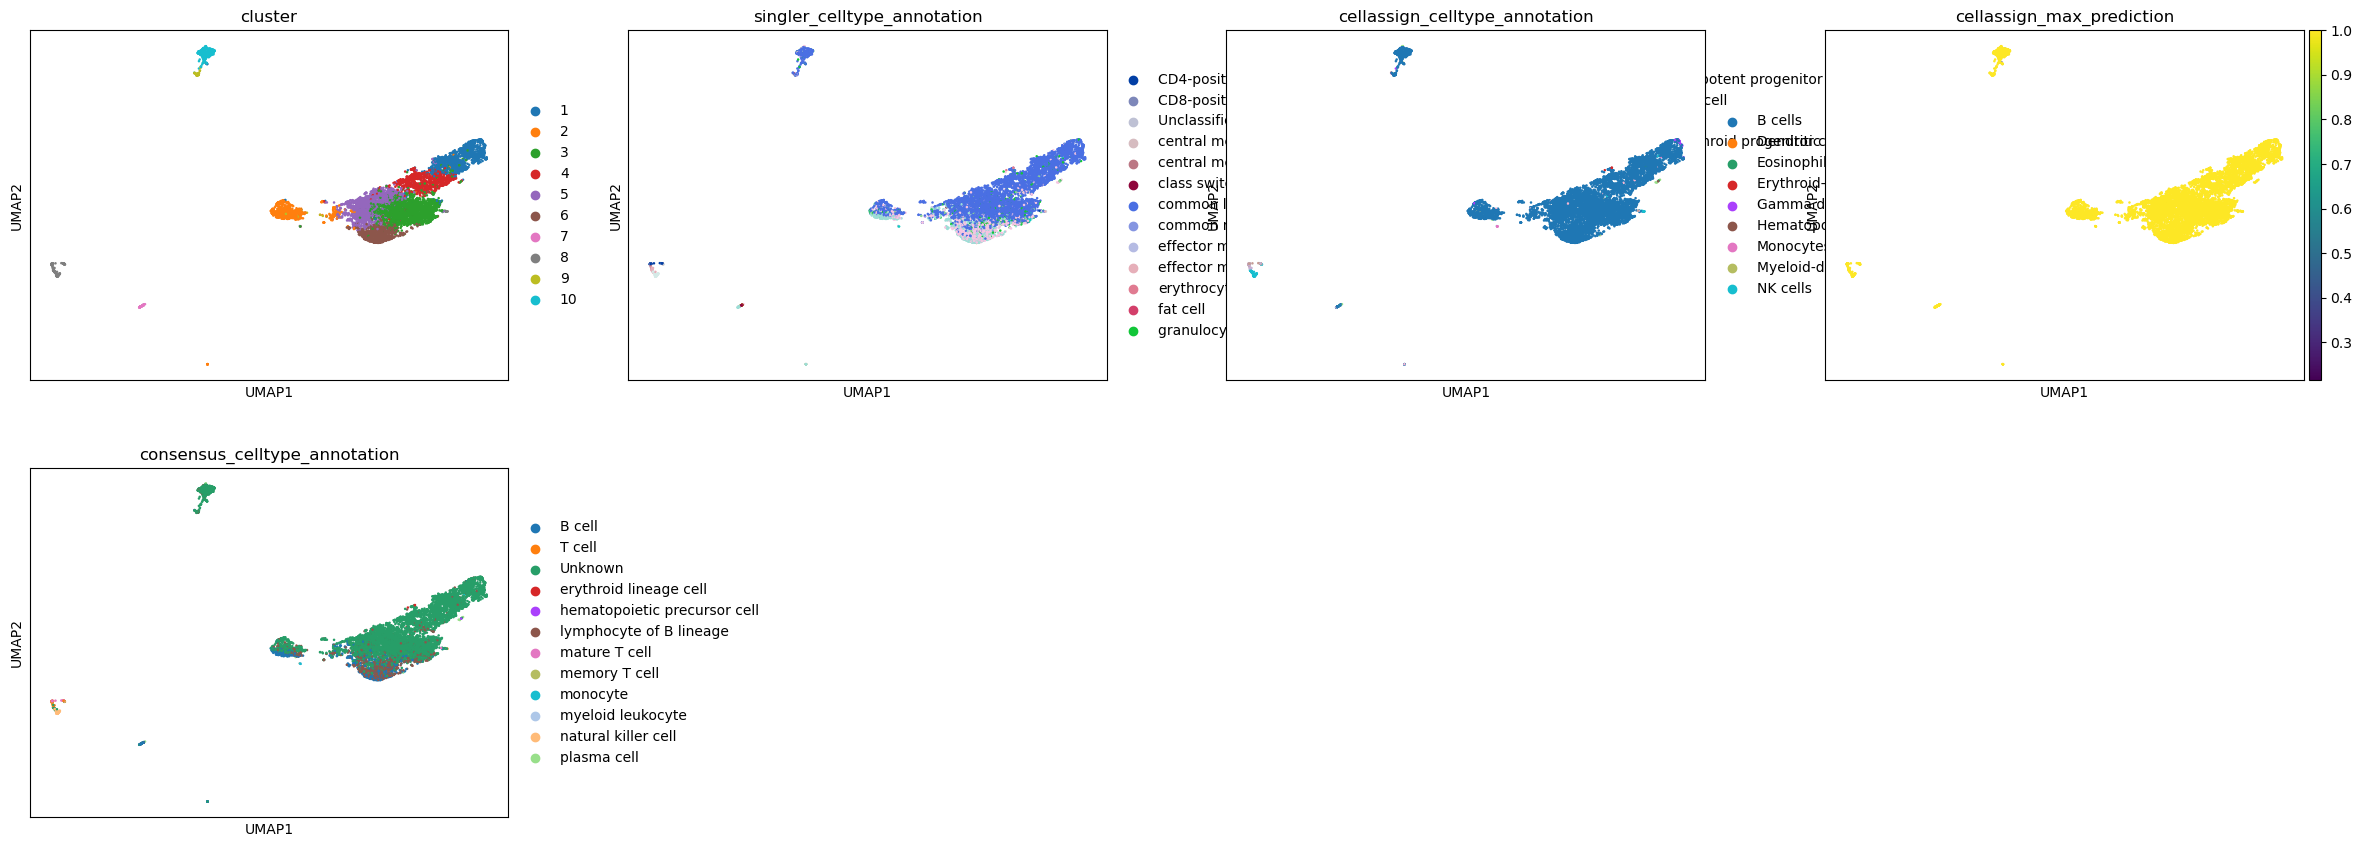

In [ ]:
sc.pl.embedding(anndata, basis="umap", color=['cluster', 'singler_celltype_annotation', 'cellassign_celltype_annotation', 'cellassign_max_prediction', 'consensus_celltype_annotation'])
# Cell type annotations for humans.

In [ ]:
sc.pl.embedding(anndata, basis="umap", color=['cluster', 'singler_celltype_ontology', 'cellassign_celltype_ontology', 'consensus_celltype_ontology'])
# Ontology tags standardize the expression profiles that automated cell sorting packages/algorithms generate. This allows us to discuss cell exppression without,
# the confusion of human standard names such as B-Cell or HMC. Basically names for machines not humans, more precise less vague.

NameError: name 'sc' is not defined